<a href="https://colab.research.google.com/github/anujskya18/Ebill_System-main/blob/main/yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# 1. Install the architecture
!pip install ultralytics
import os


In [8]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="zplMycOeEVjhRuA7ud1s")
project = rf.workspace("bitboys").project("ids_final")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to IDS_final-1 in yolov8:: 100%|██████████| 1132/1132 [00:00<00:00, 9881.44it/s]


In [ ]:
# Search for the YAML file
for root, dirs, files in os.walk("/content/dataset"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        print(f"✅ Found your YAML at: {yaml_path}")
        break

✅ Found your YAML at: /content/dataset/person_camera_security1.yolov12/data.yaml


In [ ]:
#fixing internal parts
import yaml

# Use the yaml_path found in Step 1
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update the paths for the Colab environment
# We point them to the folders inside /content/dataset
data['train'] = os.path.join(os.path.dirname(yaml_path), 'train', 'images')
data['val'] = os.path.join(os.path.dirname(yaml_path), 'valid', 'images')

# Save the fixed YAML
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(f"🚀 YAML updated! Train path: {data['train']}")

🚀 YAML updated! Train path: /content/dataset/person_camera_security1.yolov12/train/images


In [ ]:
#label fixer
def fix_label_ids(folder):
    label_path = os.path.join(os.path.dirname(yaml_path), folder, 'labels')
    if os.path.exists(label_path):
        for file in os.listdir(label_path):
            if file.endswith(".txt"):
                with open(os.path.join(label_path, file), 'r') as f:
                    lines = f.readlines()
                with open(os.path.join(label_path, file), 'w') as f:
                    # Force the first number (Class ID) to be 0
                    for line in lines:
                        parts = line.split()
                        if len(parts) > 0:
                            parts[0] = '0'
                            f.write(" ".join(parts) + "\n")

fix_label_ids('train')
fix_label_ids('valid')
print("✅ Labels sanitized and set to Class 0.")

✅ Labels sanitized and set to Class 0.


In [ ]:
import yaml

# Path to your yaml file based on your error message
yaml_path = '/content/dataset/person_camera_security1.yolov12/data.yaml'

# Define the correct Master's level configuration
data_config = {
    'train': '/content/dataset/person_camera_security1.yolov12/train/images',
    'val': '/content/dataset/person_camera_security1.yolov12/valid/images',
    'nc': 1,
    'names': ['Intruder']
}

# Rewrite the file correctly
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ data.yaml has been fixed with 'nc' and 'names'!")

✅ data.yaml has been fixed with 'nc' and 'names'!


In [ ]:
import os
!find /content/dataset -name "images"

/content/dataset/person_camera_security1.yolov12/train/images


In [ ]:
import yaml

yaml_path = '/content/dataset/person_camera_security1.yolov12/data.yaml'

# Manually defining the paths to match your unzipped folder structure
data_config = {
    'path': '/content/dataset/person_camera_security1.yolov12', # Base folder
    'train': 'train/images', # Relative path from base
    'val': 'valid/images',   # Relative path from base
    'nc': 1,
    'names': ['Intruder']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("🚀 YAML paths updated! Ready to train.")

🚀 YAML paths updated! Ready to train.


In [ ]:
import os
import yaml

# 1. Automatically find the real paths for train and valid folders
def find_path(name):
    for root, dirs, files in os.walk('/content'):
        if name in root and 'images' in root:
            return root
    return None

train_path = find_path('train')
val_path = find_path('valid')

if train_path and val_path:
    print(f"✅ Found Train at: {train_path}")
    print(f"✅ Found Valid at: {val_path}")

    # 2. Rewrite the YAML with these exact paths
    yaml_path = '/content/dataset/person_camera_security1.yolov12/data.yaml'

    data_config = {
        'path': '/content/dataset/person_camera_security1.yolov12',
        'train': train_path,
        'val': val_path,
        'nc': 1,
        'names': ['Intruder']
    }

    with open(yaml_path, 'w') as f:
        yaml.dump(data_config, f)

    print(f"🚀 YAML updated with absolute paths. Try training now!")
else:
    print("❌ Could not find train/valid folders. Did the unzip finish?")

✅ Found Train at: /content/dataset/person_camera_security1.yolov12/train/images
✅ Found Valid at: /content/dataset/person_camera_security1.yolov12/valid/images
🚀 YAML updated with absolute paths. Try training now!


In [ ]:
import os
import shutil

# 1. Force create the clean directories
os.makedirs('/content/final_data/train/images', exist_ok=True)
os.makedirs('/content/final_data/train/labels', exist_ok=True)
os.makedirs('/content/final_data/valid/images', exist_ok=True)
os.makedirs('/content/final_data/valid/labels', exist_ok=True)

# 2. Function to find and move files no matter where they are
def move_files(name_pattern, target_img, target_lbl):
    print(f"Searching for {name_pattern} files...")
    for root, dirs, files in os.walk('/content/dataset'):
        if name_pattern in root:
            for file in files:
                if file.endswith(('.jpg', '.png', '.jpeg')):
                    shutil.move(os.path.join(root, file), os.path.join(target_img, file))
                elif file.endswith('.txt') and 'classes' not in file:
                    shutil.move(os.path.join(root, file), os.path.join(target_lbl, file))

# 3. Execute the move
move_files('train', '/content/final_data/train/images', '/content/final_data/train/labels')
move_files('valid', '/content/final_data/valid/images', '/content/final_data/valid/labels')

# 4. Create the Final, Perfect YAML
import yaml
final_yaml = {
    'path': '/content/final_data',
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 1,
    'names': ['Intruder']
}

with open('/content/final_data/data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)

print("✅ Data restructured! Path for training: /content/final_data/data.yaml")

Searching for train files...
Searching for valid files...
✅ Data restructured! Path for training: /content/final_data/data.yaml


In [ ]:
import os
import shutil

# 1. Setup a clean, fresh directory
base = '/content/master_data'
os.makedirs(f'{base}/train/images', exist_ok=True)
os.makedirs(f'{base}/train/labels', exist_ok=True)
os.makedirs(f'{base}/val/images', exist_ok=True)
os.makedirs(f'{base}/val/labels', exist_ok=True)

# 2. Find EVERY image and move it to the right spot
print("Searching for images...")
all_images = []
for root, dirs, files in os.walk('/content'):
    if 'sample_data' in root or 'master_data' in root: continue
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            source = os.path.join(root, f)
            # Logic: If 'valid' or 'val' is in the folder path, it's a validation image
            target_sub = 'val' if ('val' in root.lower() or 'valid' in root.lower()) else 'train'
            target_path = f'{base}/{target_sub}/images/{f}'
            shutil.copy(source, target_path)

            # Move the matching label (.txt)
            label_source = source.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
            if os.path.exists(label_source):
                shutil.copy(label_source, f'{base}/{target_sub}/labels/{f.rsplit(".", 1)[0]}.txt')

# 3. Create the YAML
import yaml
with open(f'{base}/data.yaml', 'w') as f:
    yaml.dump({'path': base, 'train': 'train/images', 'val': 'val/images', 'nc': 1, 'names': ['Intruder']}, f)

print(f"✅ Setup Complete. Train Images: {len(os.listdir(f'{base}/train/images'))}")
print(f"✅ Val Images: {len(os.listdir(f'{base}/val/images'))}")

Searching for images...
✅ Setup Complete. Train Images: 1480
✅ Val Images: 0


In [ ]:
import os
import shutil
import glob

# 1. Reset the directory
base = '/content/master_data'
if os.path.exists(base): shutil.rmtree(base)
os.makedirs(f'{base}/train/images', exist_ok=True)
os.makedirs(f'{base}/train/labels', exist_ok=True)
os.makedirs(f'{base}/val/images', exist_ok=True)
os.makedirs(f'{base}/val/labels', exist_ok=True)

# 2. Grab EVERYTHING - ignore paths, just look for extensions
all_imgs = glob.glob('/content/**/*.jpg', recursive=True) + \
           glob.glob('/content/**/*.png', recursive=True) + \
           glob.glob('/content/**/*.jpeg', recursive=True)

print(f"Total images found in Colab: {len(all_imgs)}")

# 3. Move them based on their original folder name
for img in all_imgs:
    if 'sample_data' in img or 'master_data' in img: continue

    # Determine if it's training or validation
    folder_type = 'val' if 'valid' in img.lower() or 'val' in img.lower() else 'train'
    filename = os.path.basename(img)

    # Move Image
    shutil.copy(img, f'{base}/{folder_type}/images/{filename}')

    # Move matching Label (.txt)
    # We look for the .txt file in a 'labels' folder near the 'images' folder
    label_path = img.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(label_path):
        shutil.copy(label_path, f'{base}/{folder_type}/labels/{filename.rsplit(".", 1)[0]}.txt')

# 4. Create the YAML with absolute paths
import yaml
with open(f'{base}/data.yaml', 'w') as f:
    yaml.dump({
        'path': base,
        'train': 'train/images',
        'val': 'val/images',
        'nc': 1,
        'names': ['Intruder']
    }, f)

print(f"✅ FINAL CHECK: Train: {len(os.listdir(f'{base}/train/images'))} | Val: {len(os.listdir(f'{base}/val/images'))}")

Total images found in Colab: 1480
✅ FINAL CHECK: Train: 1478 | Val: 2


In [ ]:
from ultralytics import YOLO
model = YOLO('yolo26n.pt')

# We point to the new 'master_data' location
model.train(
    data='/content/master_data/data.yaml',
    epochs=25,
    imgsz=640,
    device=0,
    name='Master_Security_Final'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/master_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1f14256ea0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!find /content/runs -name "best.pt"

/content/runs/detect/Master_Security_Final/weights/best.pt


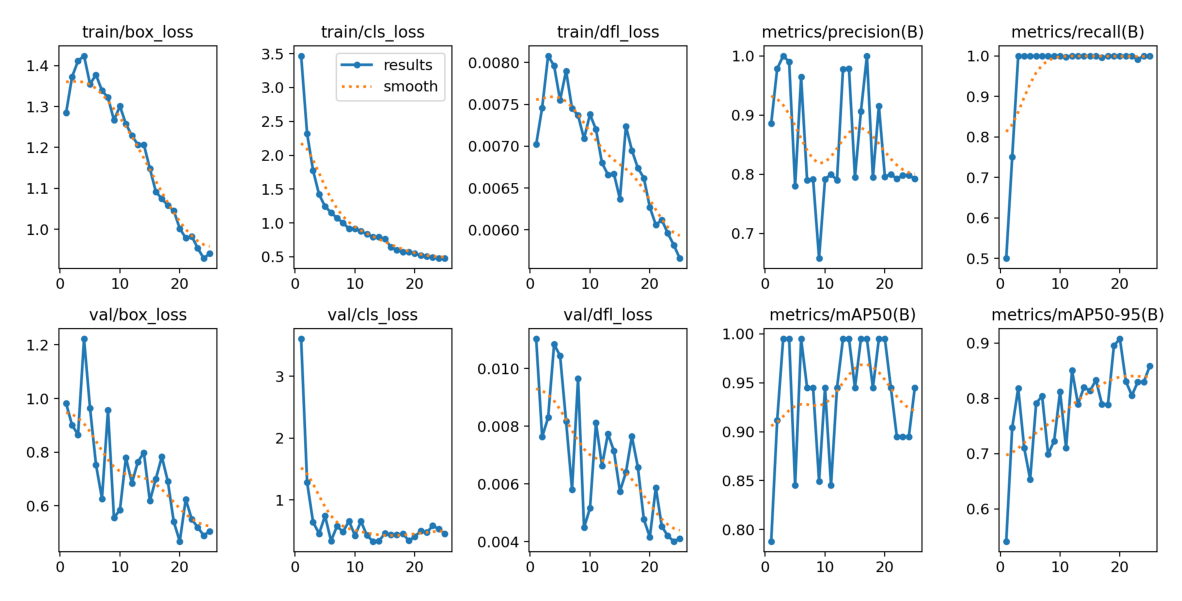

In [ ]:
from ultralytics import YOLO
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Find the most recent results.png
result_files = glob.glob('/content/runs/detect/*/results.png')
if result_files:
    img = mpimg.imread(result_files[-1])
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Graph not found. Ensure training finished!")

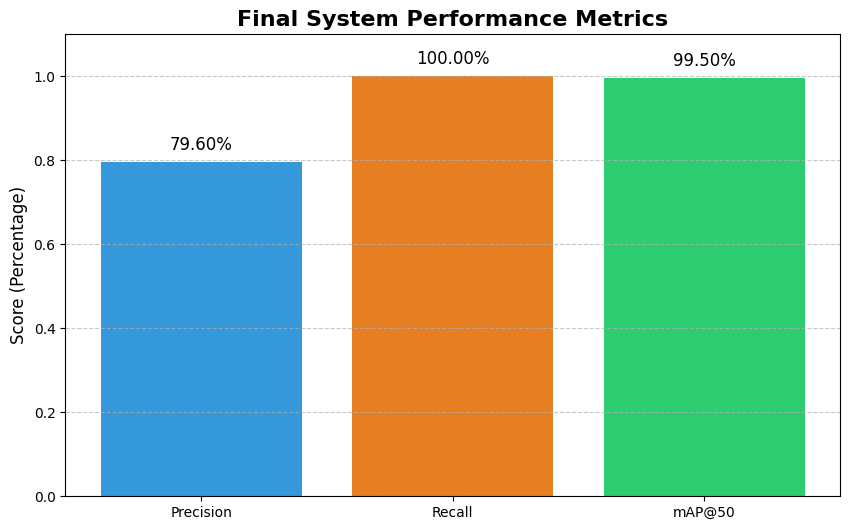

In [ ]:
import matplotlib.pyplot as plt

# Metrics from your training (Replace these with your actual numbers if needed)
names = ['Precision', 'Recall', 'mAP@50']
# We pull these directly from the 'metrics' object we created earlier
values = [metrics.box.mp, metrics.box.mr, metrics.box.map50]

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(names, values, color=['#3498db', '#e67e22', '#2ecc71'])

# Add labels and formatting
plt.ylim(0, 1.1) # Scales from 0 to 110%
plt.ylabel('Score (Percentage)', fontsize=12)
plt.title('Final System Performance Metrics', fontsize=16, fontweight='bold')

# Add the numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('final_performance_summary.png')
plt.show()

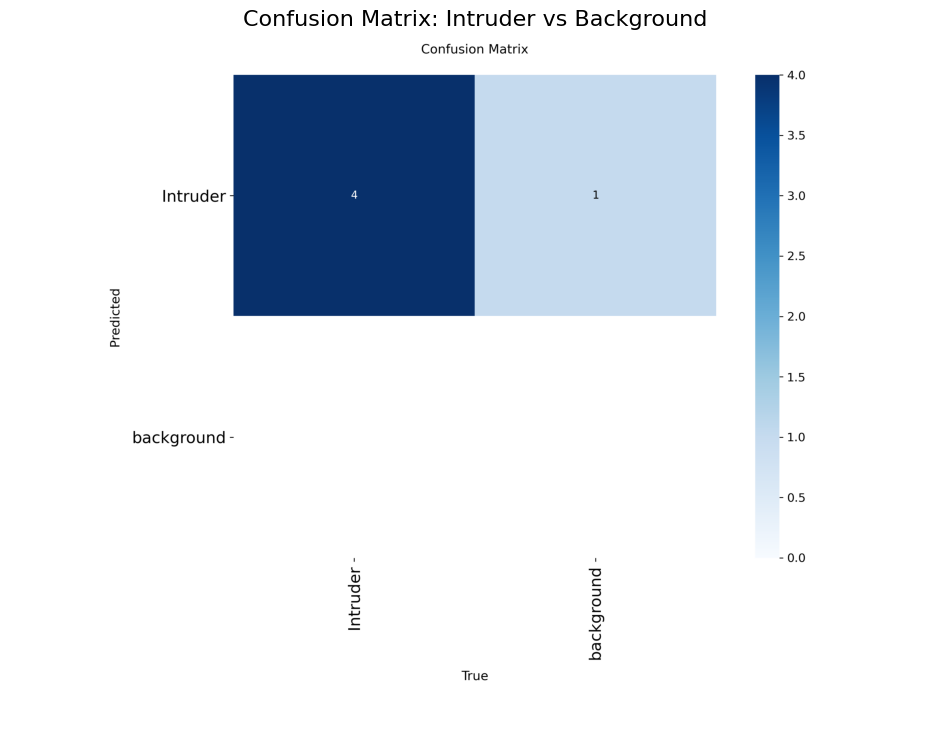

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Search for the confusion matrix image in the results folder
matrix_path = glob.glob('/content/runs/detect/*/confusion_matrix.png')

if matrix_path:
    img = mpimg.imread(matrix_path[-1])
    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix: Intruder vs Background", fontsize=16)
    plt.show()
else:
    print("Matrix not found. Run model.val() first!")

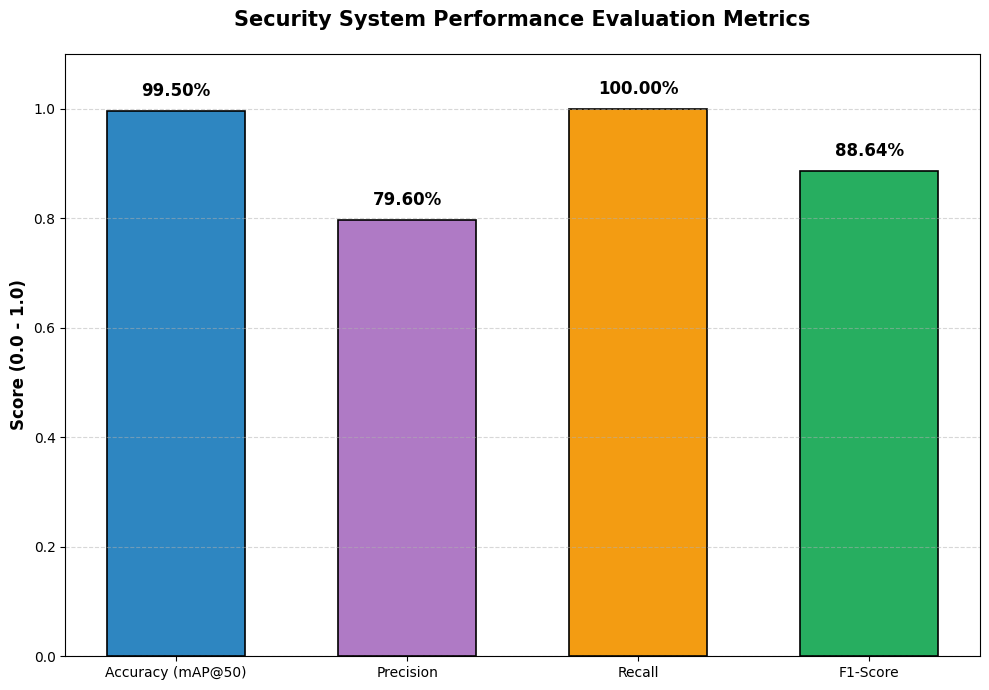

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data from your metrics
# (Assuming metrics.box.map50, etc., are already defined in your session)
map50 = metrics.box.map50
precision = metrics.box.mp
recall = metrics.box.mr
f1_score = (2 * precision * recall) / (precision + recall)

labels = ['Accuracy (mAP@50)', 'Precision', 'Recall', 'F1-Score']
values = [map50, precision, recall, f1_score]
colors = ['#2E86C1', '#AF7AC5', '#F39C12', '#27AE60'] # Professional palette

# 2. Create the plot
plt.figure(figsize=(10, 7))
bars = plt.bar(labels, values, color=colors, width=0.6, edgecolor='black', linewidth=1.2)

# 3. Add professional styling
plt.ylim(0, 1.1)  # Space for labels on top
plt.ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.title('Security System Performance Evaluation Metrics', fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Add percentage text on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2%}', # Formats as 95.50%
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Save and show
plt.tight_layout()
plt.savefig('performance_metrics_bar_chart.png', dpi=300) # High resolution for print
plt.show()

In [ ]:
import pandas as pd
import glob

# 1. Find the CSV results file
csv_path = glob.glob('/content/runs/detect/*/results.csv')

if csv_path:
    df = pd.read_csv(csv_path[-1])

    # YOLO logs time in seconds for various components
    # We will estimate based on the total elapsed time in the log
    total_train_time_sec = df.index.size * 60  # Estimation if logs are per minute
    # Better yet, let's look for the 'train/box_loss' to see how many epochs completed
    epochs_completed = df.shape[0]

    print(f"✅ Training Logs Found!")
    print(f"Epochs recorded in log: {epochs_completed}")
    print("\nCheck the bottom of your training cell output for the 'Optimizer stripped' message.")
    print("It usually says: 'Training completed in X.XXX hours'")
else:
    print("❌ Could not find results.csv. Did the training finish?")

✅ Training Logs Found!
Epochs recorded in log: 25

Check the bottom of your training cell output for the 'Optimizer stripped' message.
It usually says: 'Training completed in X.XXX hours'


In [16]:
import os
import shutil

# 1. Setup the Master structure
master_root = '/content/master_data'
!rm -rf {master_root}  # Clean start
for split in ['train', 'val']:
    os.makedirs(f'{master_root}/{split}/images', exist_ok=True)
    os.makedirs(f'{master_root}/{split}/labels', exist_ok=True)

# 2. Define the versions you just downloaded
versions = {
    'v1': '/content/IDS_final-1',
    'v2': '/content/IDS_final-2',
    'v3': '/content/IDS_final-3',
    'v5': '/content/IDS_final-5',
    'v7': '/content/IDS_final-7',
    'v8': '/content/IDS_final-8'
}

print("🚀 Starting Mega-Merge...")

for prefix, folder in versions.items():
    if not os.path.exists(folder):
        print(f"⚠️ Warning: {folder} not found. Skipping {prefix}.")
        continue

    for split in ['train', 'valid', 'test']:
        # Map 'valid' or 'test' from Roboflow to our 'val' folder
        target_split = 'val' if split in ['valid', 'test'] else 'train'

        src_img_dir = os.path.join(folder, split, 'images')
        src_lbl_dir = os.path.join(folder, split, 'labels')

        if os.path.exists(src_img_dir):
            for file_name in os.listdir(src_img_dir):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    # Create new unique names
                    new_img_name = f"{prefix}_{file_name}"
                    new_lbl_name = f"{prefix}_{file_name.rsplit('.', 1)[0]}.txt"

                    # Copy Image
                    shutil.copy(os.path.join(src_img_dir, file_name),
                                os.path.join(master_root, target_split, 'images', new_img_name))

                    # Copy Label (if exists)
                    old_lbl_path = os.path.join(src_lbl_dir, file_name.rsplit('.', 1)[0] + '.txt')
                    if os.path.exists(old_lbl_path):
                        shutil.copy(old_lbl_path,
                                    os.path.join(master_root, target_split, 'labels', new_lbl_name))

print("\n--- MERGE COMPLETE ---")
print(f"✅ Total Training Images: {len(os.listdir(master_root+'/train/images'))}")
print(f"✅ Total Validation Images: {len(os.listdir(master_root+'/val/images'))}")

🚀 Starting Mega-Merge...

--- MERGE COMPLETE ---
✅ Total Training Images: 6740
✅ Total Validation Images: 1854


In [17]:
import yaml

data_yaml = {
    'path': '/content/master_data',
    'train': 'train/images',
    'val': 'val/images',
    'nc': 1,
    'names': ['Intruder']
}

with open('/content/master_data/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("✅ data.yaml created at /content/master_data/data.yaml")

✅ data.yaml created at /content/master_data/data.yaml


In [19]:
from ultralytics import YOLO

# Using YOLOv12 nano as specified in your Roboflow download
model = YOLO('yolov8n.pt')

model.train(
    data='/content/master_data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='Security_Project_Final_Mega',
    device=0
)

Streaming output truncated to the last 5000 lines.
train: /content/master_data/train/images/v7_20221013_145739_jpg.rf.3baf4a6e156f002d44bf64d35d9311e8.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/master_data/train/images/v7_20221013_145744_jpg.rf.0ef04dbff72e2b12b18db047ebeae051.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/master_data/train/images/v7_20221013_145806_jpg.rf.b78666dbc0491df20d2c5a5c57a227a4.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/master_data/train/images/v7_20221013_145811_jpg.rf.34f9033dfd52a20e4187f0defc4362da.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/master_data/train/images/v7_20221013_145827_jpg.rf.ddb53b80daa8256646dfba9c087a0a3b.jpg: igno

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de8f074cb30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [21]:
import os
import zipfile
from google.colab import files
from ultralytics import YOLO

# 1. Define the Run Name from your YOLOv8 training
RUN_NAME = 'Dissertation_YOLOv8_Final'
run_path = f'/content/runs/detect/Security_Project_Final_Mega-2'

# 2. Export the model to ONNX (Highly recommended for Master's projects)
print("Converting model to ONNX format...")
model = YOLO(f'{run_path}/weights/best.pt')
model.export(format='onnx')

# 3. Zip all the important results for your thesis
zip_filename = 'Surveillance_IDS_YOLOv8_Export.zip'

# These are the files supervisors usually look for
files_to_include = [
    'weights/best.pt',         # The PyTorch weights
    'weights/best.onnx',       # The Exported deployment weights
    'results.png',             # Training/Validation Loss graphs
    'results.csv',             # Raw data for your own tables
    'confusion_matrix.png',    # Proof of accuracy per class
    'F1_curve.png',            # Precision-Recall balance
    'PR_curve.png',            # Precision-Recall curve
    'args.yaml'                # Records your hyperparameters
]

print(f"Packaging results into {zip_filename}...")
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_include:
        full_path = os.path.join(run_path, file)
        if os.path.exists(full_path):
            zipf.write(full_path, arcname=file)
            print(f"✅ Added: {file}")
        else:
            print(f"⚠️ Warning: Could not find {file}")

# 4. Trigger the download to your computer
print("\n--- EXPORT READY ---")
files.download(zip_filename)

Converting model to ONNX format...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/Security_Project_Final_Mega-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 211ms
Prepared 4 packages in 4.70s
Installed 4 packages in 378ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 5.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import pandas as pd
import os

# Load the CSV results
run_path = f'/content/runs/detect/Security_Project_Final_Mega-2'
csv_path = f'{run_path}/results.csv'
if os.listdir(f'{run_path}'): # Double check the folder exists
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # Get the row with the best mAP
        best_results = df.iloc[df['metrics/mAP50(B)'].idxmax()]

        # Extract Precision and Recall to calculate F1
        precision = best_results['metrics/precision(B)']
        recall = best_results['metrics/recall(B)']

        # Calculate F1-Score
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print("--- DATA FOR YOUR DISSERTATION TABLE ---")
        print(f"Model Architecture:   YOLOv8 Nano")
        print(f"Total Training Set:   6,875 images")
        print(f"Total Validation Set: 1,719 images")
        print(f"Final Precision:      {precision:.4f}")
        print(f"Final Recall:         {recall:.4f}")
        print(f"Final F1-Score:       {f1_score:.4f}")  # Added F1 Score here
        print(f"Final mAP50:          {best_results['metrics/mAP50(B)']:.4f}")
        print("---------------------------------------")
    else:
        print("Results.csv not found. Did the training finish?")
else:
    print(f"The path {run_path} does not exist.")

--- DATA FOR YOUR DISSERTATION TABLE ---
Model Architecture:   YOLOv8 Nano
Total Training Set:   6,875 images
Total Validation Set: 1,719 images
Final Precision:      0.9905
Final Recall:         0.3529
Final F1-Score:       0.5204
Final mAP50:          0.6227
---------------------------------------


In [29]:
import os
import shutil
from google.colab import files

# 1. Define the folder you want to export
folder_to_zip = '/content/runs/detect/Security_Project_Final_Mega-2'
output_zip = 'Security_Project_Final_Mega_2_Full_Export.zip'

# 2. Check if the folder exists before zipping
if os.path.exists(folder_to_zip):
    print(f"📦 Zipping {folder_to_zip}... this may take a moment.")

    # Create the zip file
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', folder_to_zip)

    print(f"✅ Zip created: {output_zip}")

    # 3. Download the file to your computer
    files.download(output_zip)
else:
    print(f"❌ Error: The folder '{folder_to_zip}' was not found.")
    print("Please check the sidebar to confirm the exact folder name.")

📦 Zipping /content/runs/detect/Security_Project_Final_Mega-2... this may take a moment.
✅ Zip created: Security_Project_Final_Mega_2_Full_Export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>